<a href="https://colab.research.google.com/github/dokunoale/chagas/blob/prova/test_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone --branch dev --single-branch https://github.com/dokunoale/chagas.git
!pip install wfdb
!pip install -q gdown
from google.colab import drive
drive.mount('/content/drive')

import gdown
import numpy as np
import matplotlib.pyplot as plt
import wfdb
import importlib

import sys
sys.path.append('/content/chagas/src')
from preprocessing import tf_dataset_loader

url = "https://drive.google.com/uc?id=1P3blYg3gBMluOazE69ivQFyzHs7tSeq_"
gdown.download(url, "dataset.zip", quiet=False, fuzzy=True)
!unzip -q dataset.zip -d ./dataset



fatal: destination path 'chagas' already exists and is not an empty directory.
Mounted at /content/drive


Downloading...
From (original): https://drive.google.com/uc?id=1P3blYg3gBMluOazE69ivQFyzHs7tSeq_
From (redirected): https://drive.google.com/uc?id=1P3blYg3gBMluOazE69ivQFyzHs7tSeq_&confirm=t&uuid=fab5803f-9f1d-4483-af0d-8c50e4515af0
To: /content/dataset.zip
100%|██████████| 435M/435M [00:04<00:00, 90.8MB/s]


In [3]:
!cd chagas && git checkout dev && git pull origin dev

Already on 'dev'
Your branch is up to date with 'origin/dev'.
From https://github.com/dokunoale/chagas
 * branch            dev        -> FETCH_HEAD
Already up to date.


In [4]:
#Aggiorniamo tf_dataset_loader
importlib.reload(tf_dataset_loader)

# Carichiamo il dataset
X_pos, y_pos = tf_dataset_loader.load_dataset('/content/dataset/preprocessed/positives')
X_neg, y_neg = tf_dataset_loader.load_dataset('/content/dataset/preprocessed/negatives')



In [9]:
#Uniamo i positivi e i negativi
X = np.concatenate([X_pos, X_neg], axis=0)
y = np.concatenate([y_pos, y_neg], axis=0)

# Facciamo lo shuffle
indices = np.arange(X.shape[0])
np.random.shuffle(indices)

# Riordinamento di X e y con gli stessi indici
X = X[indices]
y = y[indices]

In [10]:
print(X.shape)

(7131, 2800, 12)


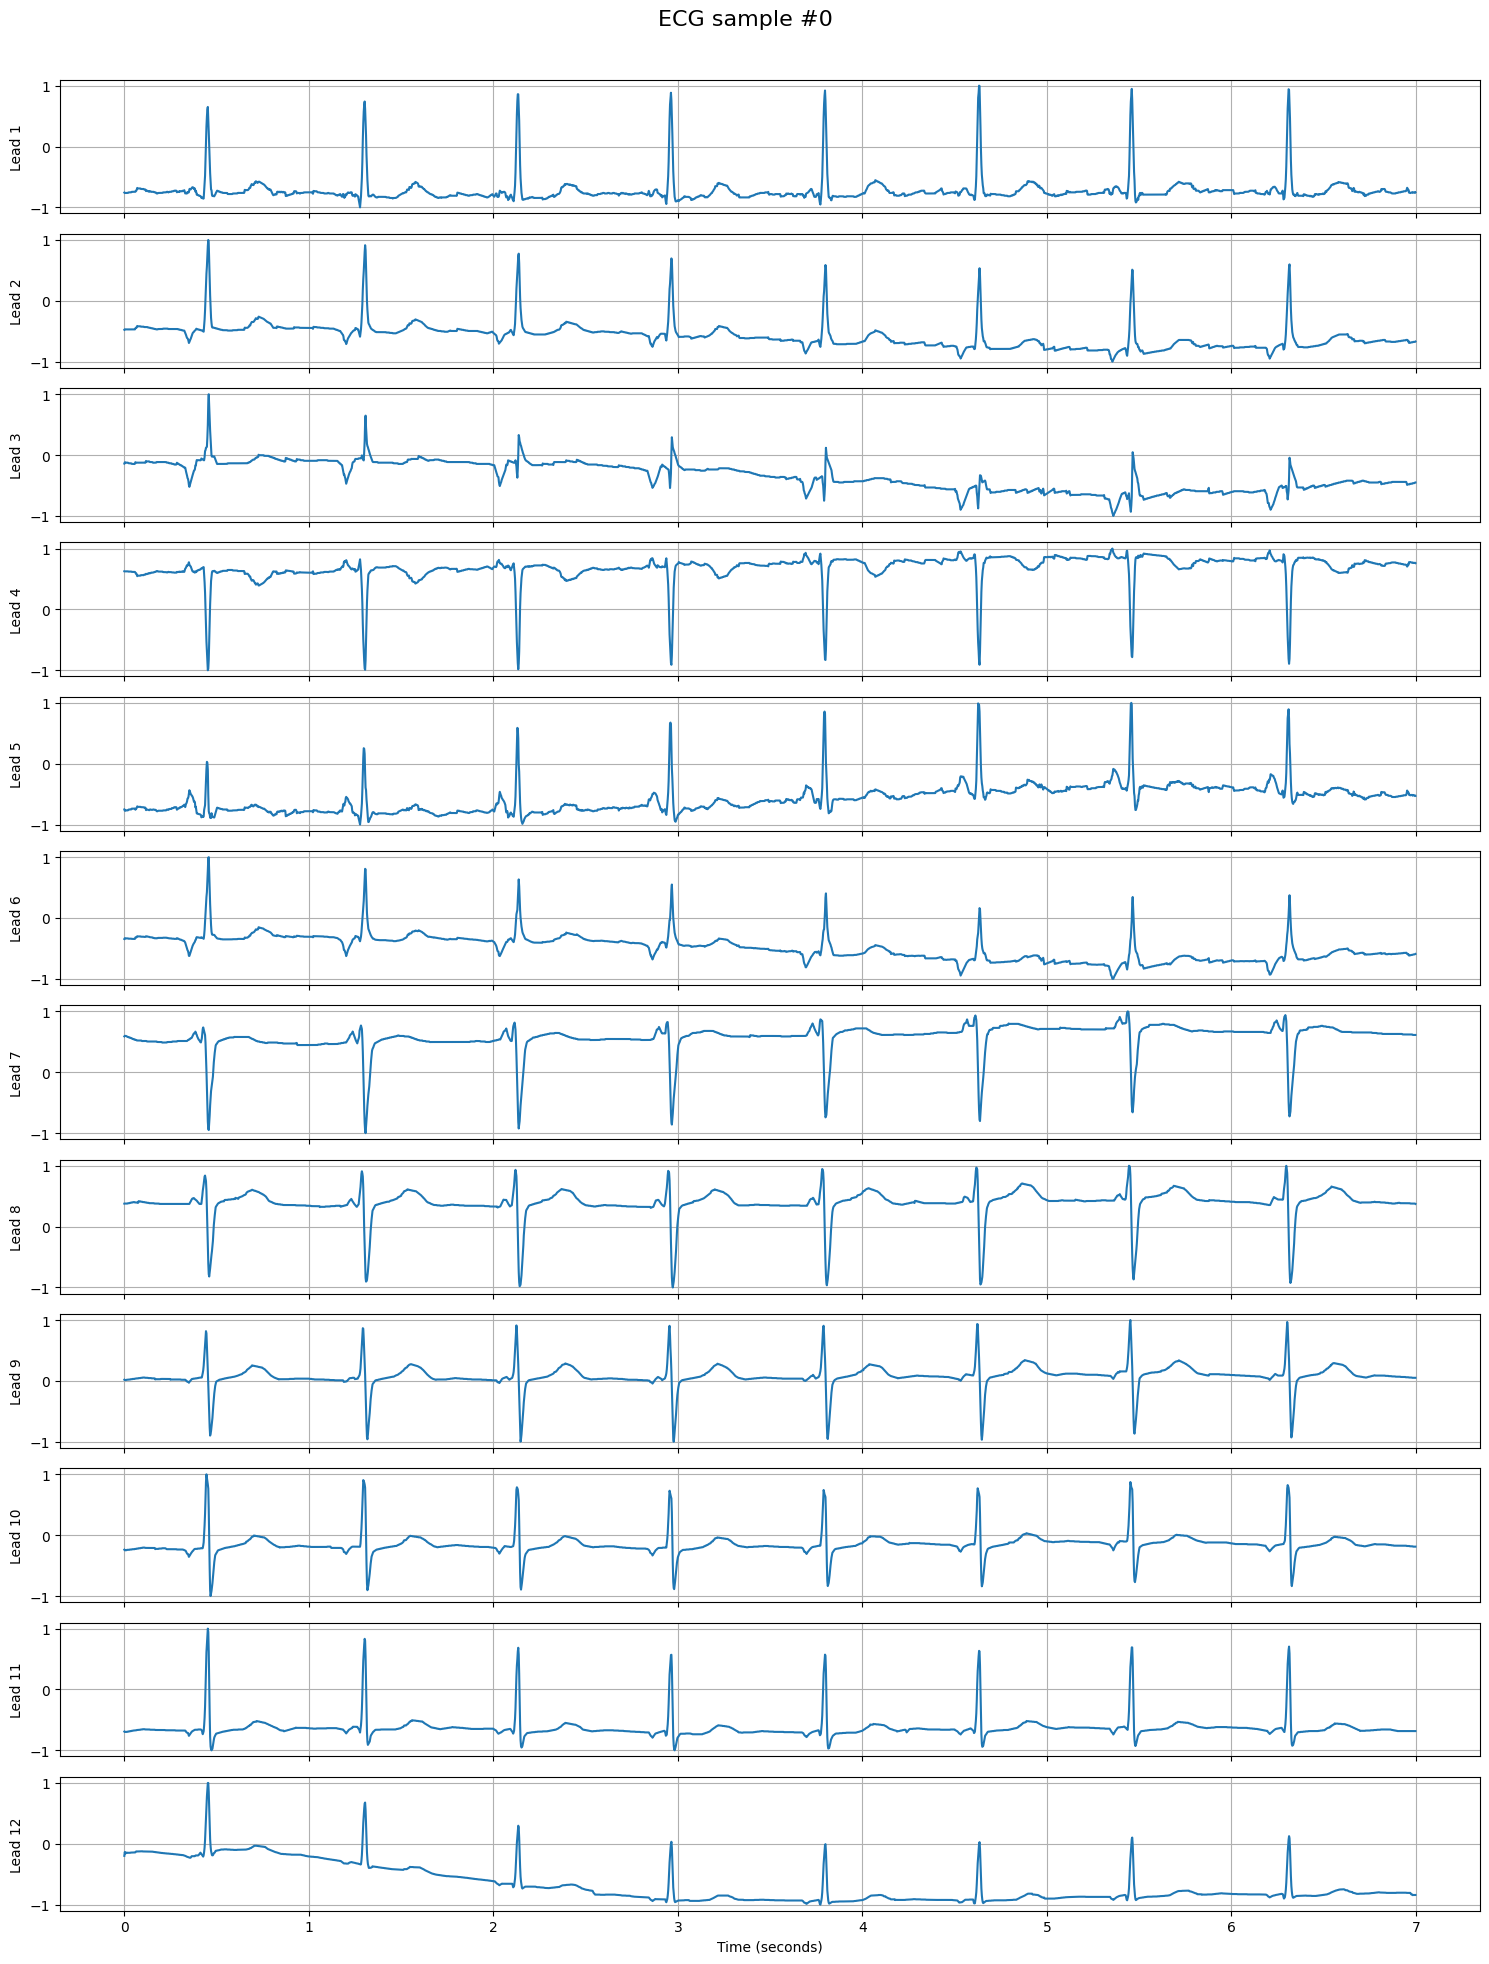

In [13]:

# Configurazione
fs = 400  # frequenza di campionamento
t = np.arange(2800) / fs  # asse temporale in secondi

def plot_ecg_sample(X, sample_idx=0):
    """Plotta le 12 derivazioni di un segnale ECG specificato da sample_idx."""
    fig, axes = plt.subplots(12, 1, figsize=(15, 20), sharex=True)
    fig.suptitle(f'ECG sample #{sample_idx}', fontsize=16)

    for i in range(12):
        axes[i].plot(t, X[sample_idx, :, i])
        axes[i].set_ylabel(f'Lead {i+1}')
        axes[i].grid(True)

    axes[-1].set_xlabel('Time (seconds)')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# Visualizza i primi 3 segnali a titolo di esempio
for idx in range(1):
    plot_ecg_sample(X, sample_idx=idx)


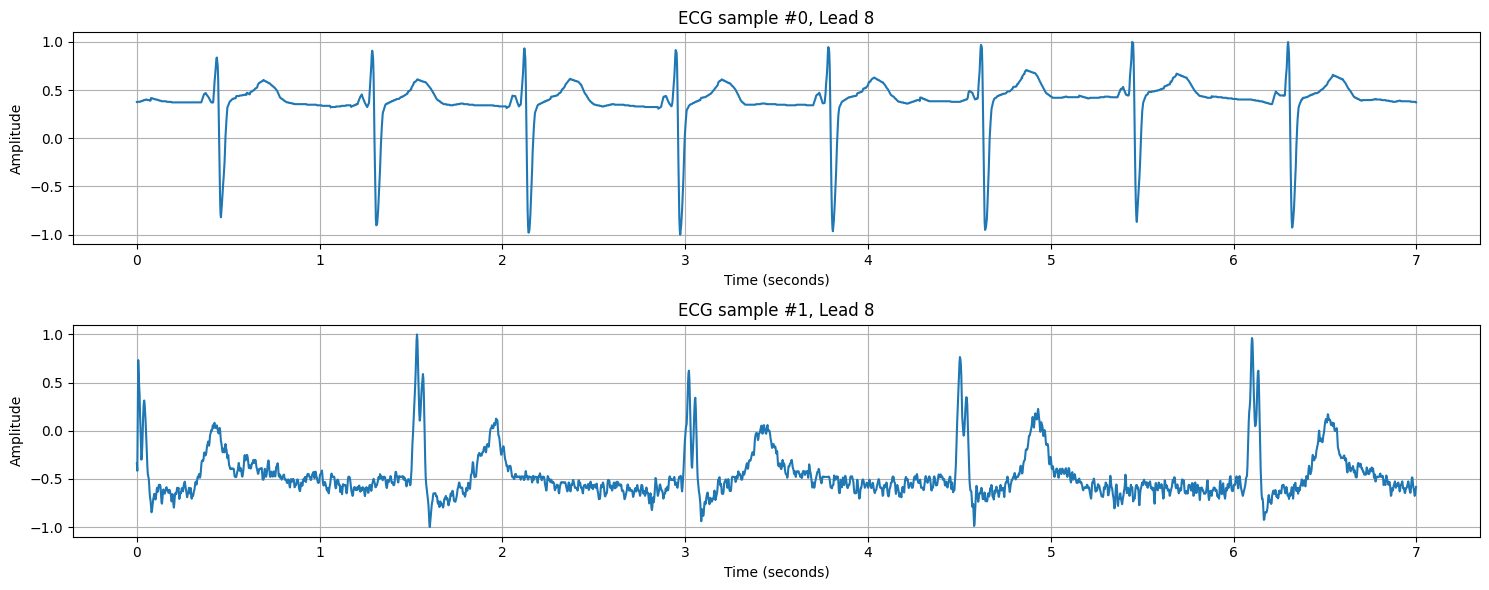

In [14]:
def plot_ecg_lead(X, samples=5, lead_idx=0):
    """
    Plotta la stessa derivazione (lead) per più segnali campione consecutivi.

    Args:
      X : np.array, shape (n_samples, n_timesteps, n_leads)
      samples : int, quanti campioni mostrare (da 0 a samples-1)
      lead_idx : int, indice della derivazione (0-based)
    """
    n_samples = X.shape[0]
    if samples > n_samples:
        raise ValueError(f"samples è maggiore del numero di segnali disponibili ({n_samples})")
    if lead_idx < 0 or lead_idx >= X.shape[2]:
        raise ValueError(f"lead_idx fuori range: deve essere tra 0 e {X.shape[2]-1}")

    plt.figure(figsize=(15, 3 * samples))
    for i in range(samples):
        plt.subplot(samples, 1, i + 1)
        plt.plot(t, X[i, :, lead_idx])
        plt.title(f'ECG sample #{i}, Lead {lead_idx + 1}')
        plt.xlabel('Time (seconds)')
        plt.ylabel('Amplitude')
        plt.grid(True)
    plt.tight_layout()
    plt.show()

# Esempio d’uso: mostra i primi 5 segnali per la derivazione 7 (indice 6 se zero-based)
plot_ecg_lead(X, samples=2, lead_idx=7)